 Heart Disease Prediction

This project uses machine learning to predict heart disease based on patient data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data loading:

In [ ]:
df=pd.read_csv('/content/merged dataset - Untitled.csv')
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


#Basic Checks:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [ ]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [ ]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [ ]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [ ]:
df.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [ ]:
df.shape

(180, 15)

In [ ]:
df.size

2700

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#EDA:

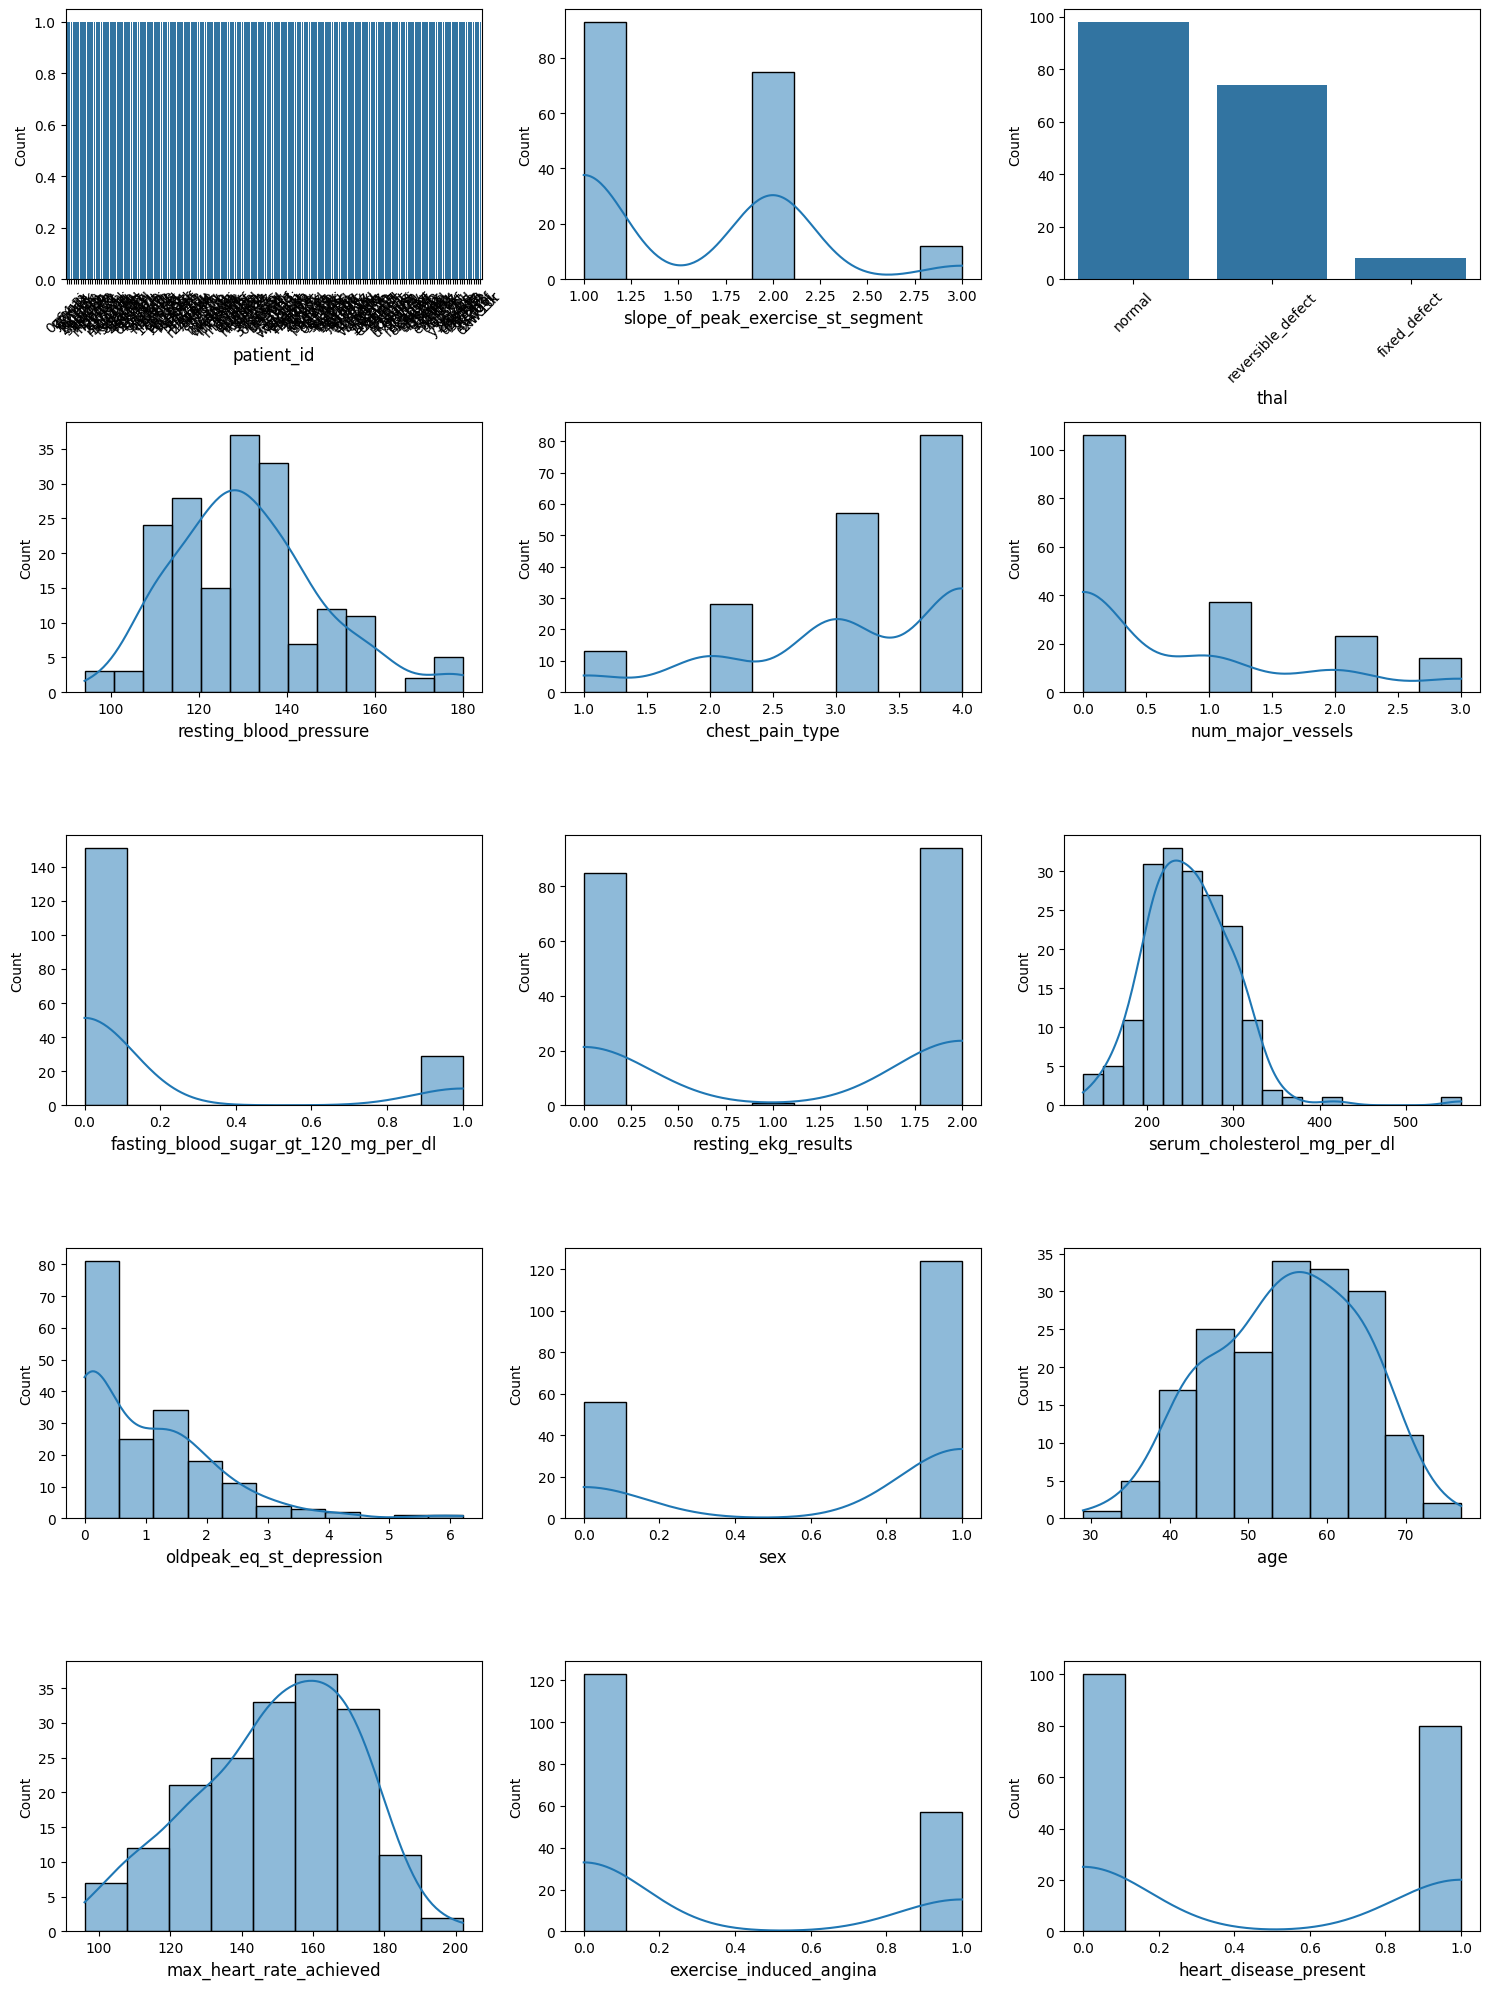

In [ ]:
num_columns = len(df.columns)
num_cols_per_row = 3
num_rows = (num_columns + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(num_cols_per_row * 5, num_rows * 4), facecolor='white')

plotnumber = 1

for column in df.columns:
    plt.subplot(num_rows, num_cols_per_row, plotnumber)

    if df[column].dtype in ['int64', 'float64']:
        sns.histplot(df[column], kde=True)
        plt.ylabel('Count')
    else:
        sns.countplot(x=df[column])
        plt.xticks(rotation=45)
        plt.ylabel('Count')

    plt.xlabel(column, fontsize=12)
    plotnumber += 1

plt.tight_layout()
plt.show()

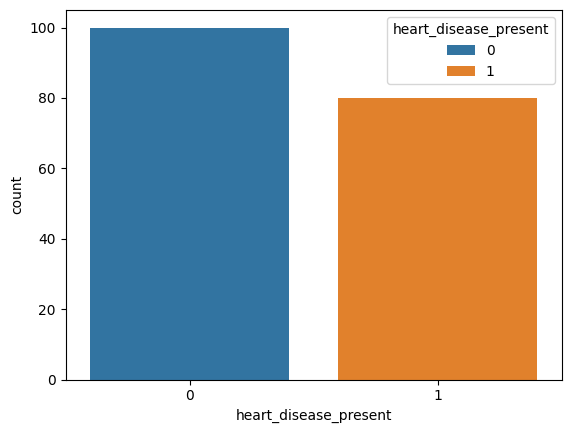

In [ ]:
#bivariate:
sns.countplot(x='heart_disease_present',hue='heart_disease_present',data=df)
plt.show()

<Axes: xlabel='chest_pain_type', ylabel='heart_disease_present'>

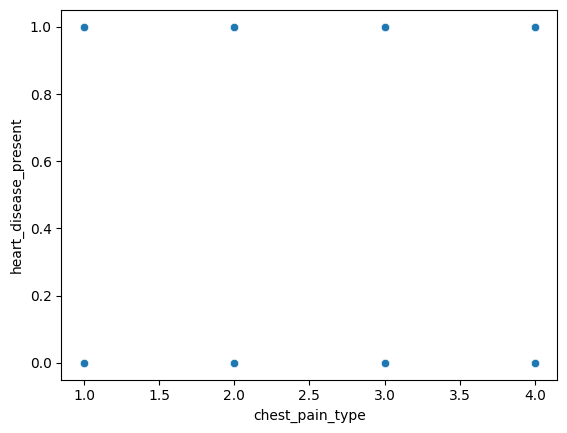

In [ ]:
sns.scatterplot(x=df['chest_pain_type'],y=df['heart_disease_present'])

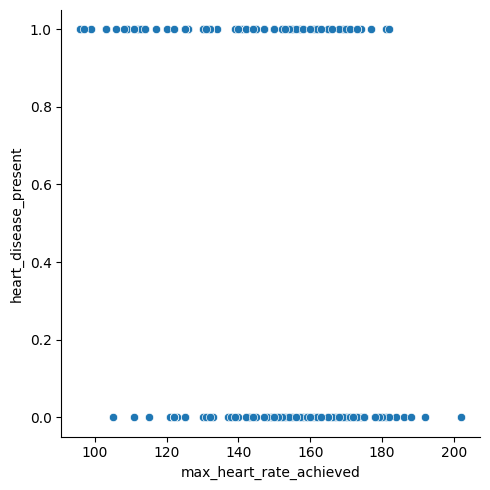

In [ ]:
sns.relplot(x='max_heart_rate_achieved',y='heart_disease_present',data=df)  #less distribution more corr

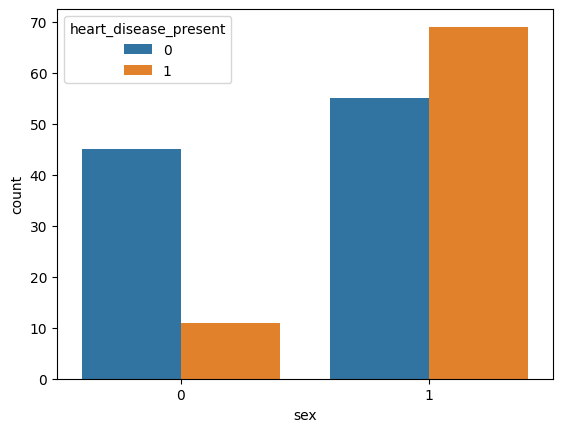

In [ ]:
sns.countplot(x='sex',hue='heart_disease_present',data=df)
plt.show()

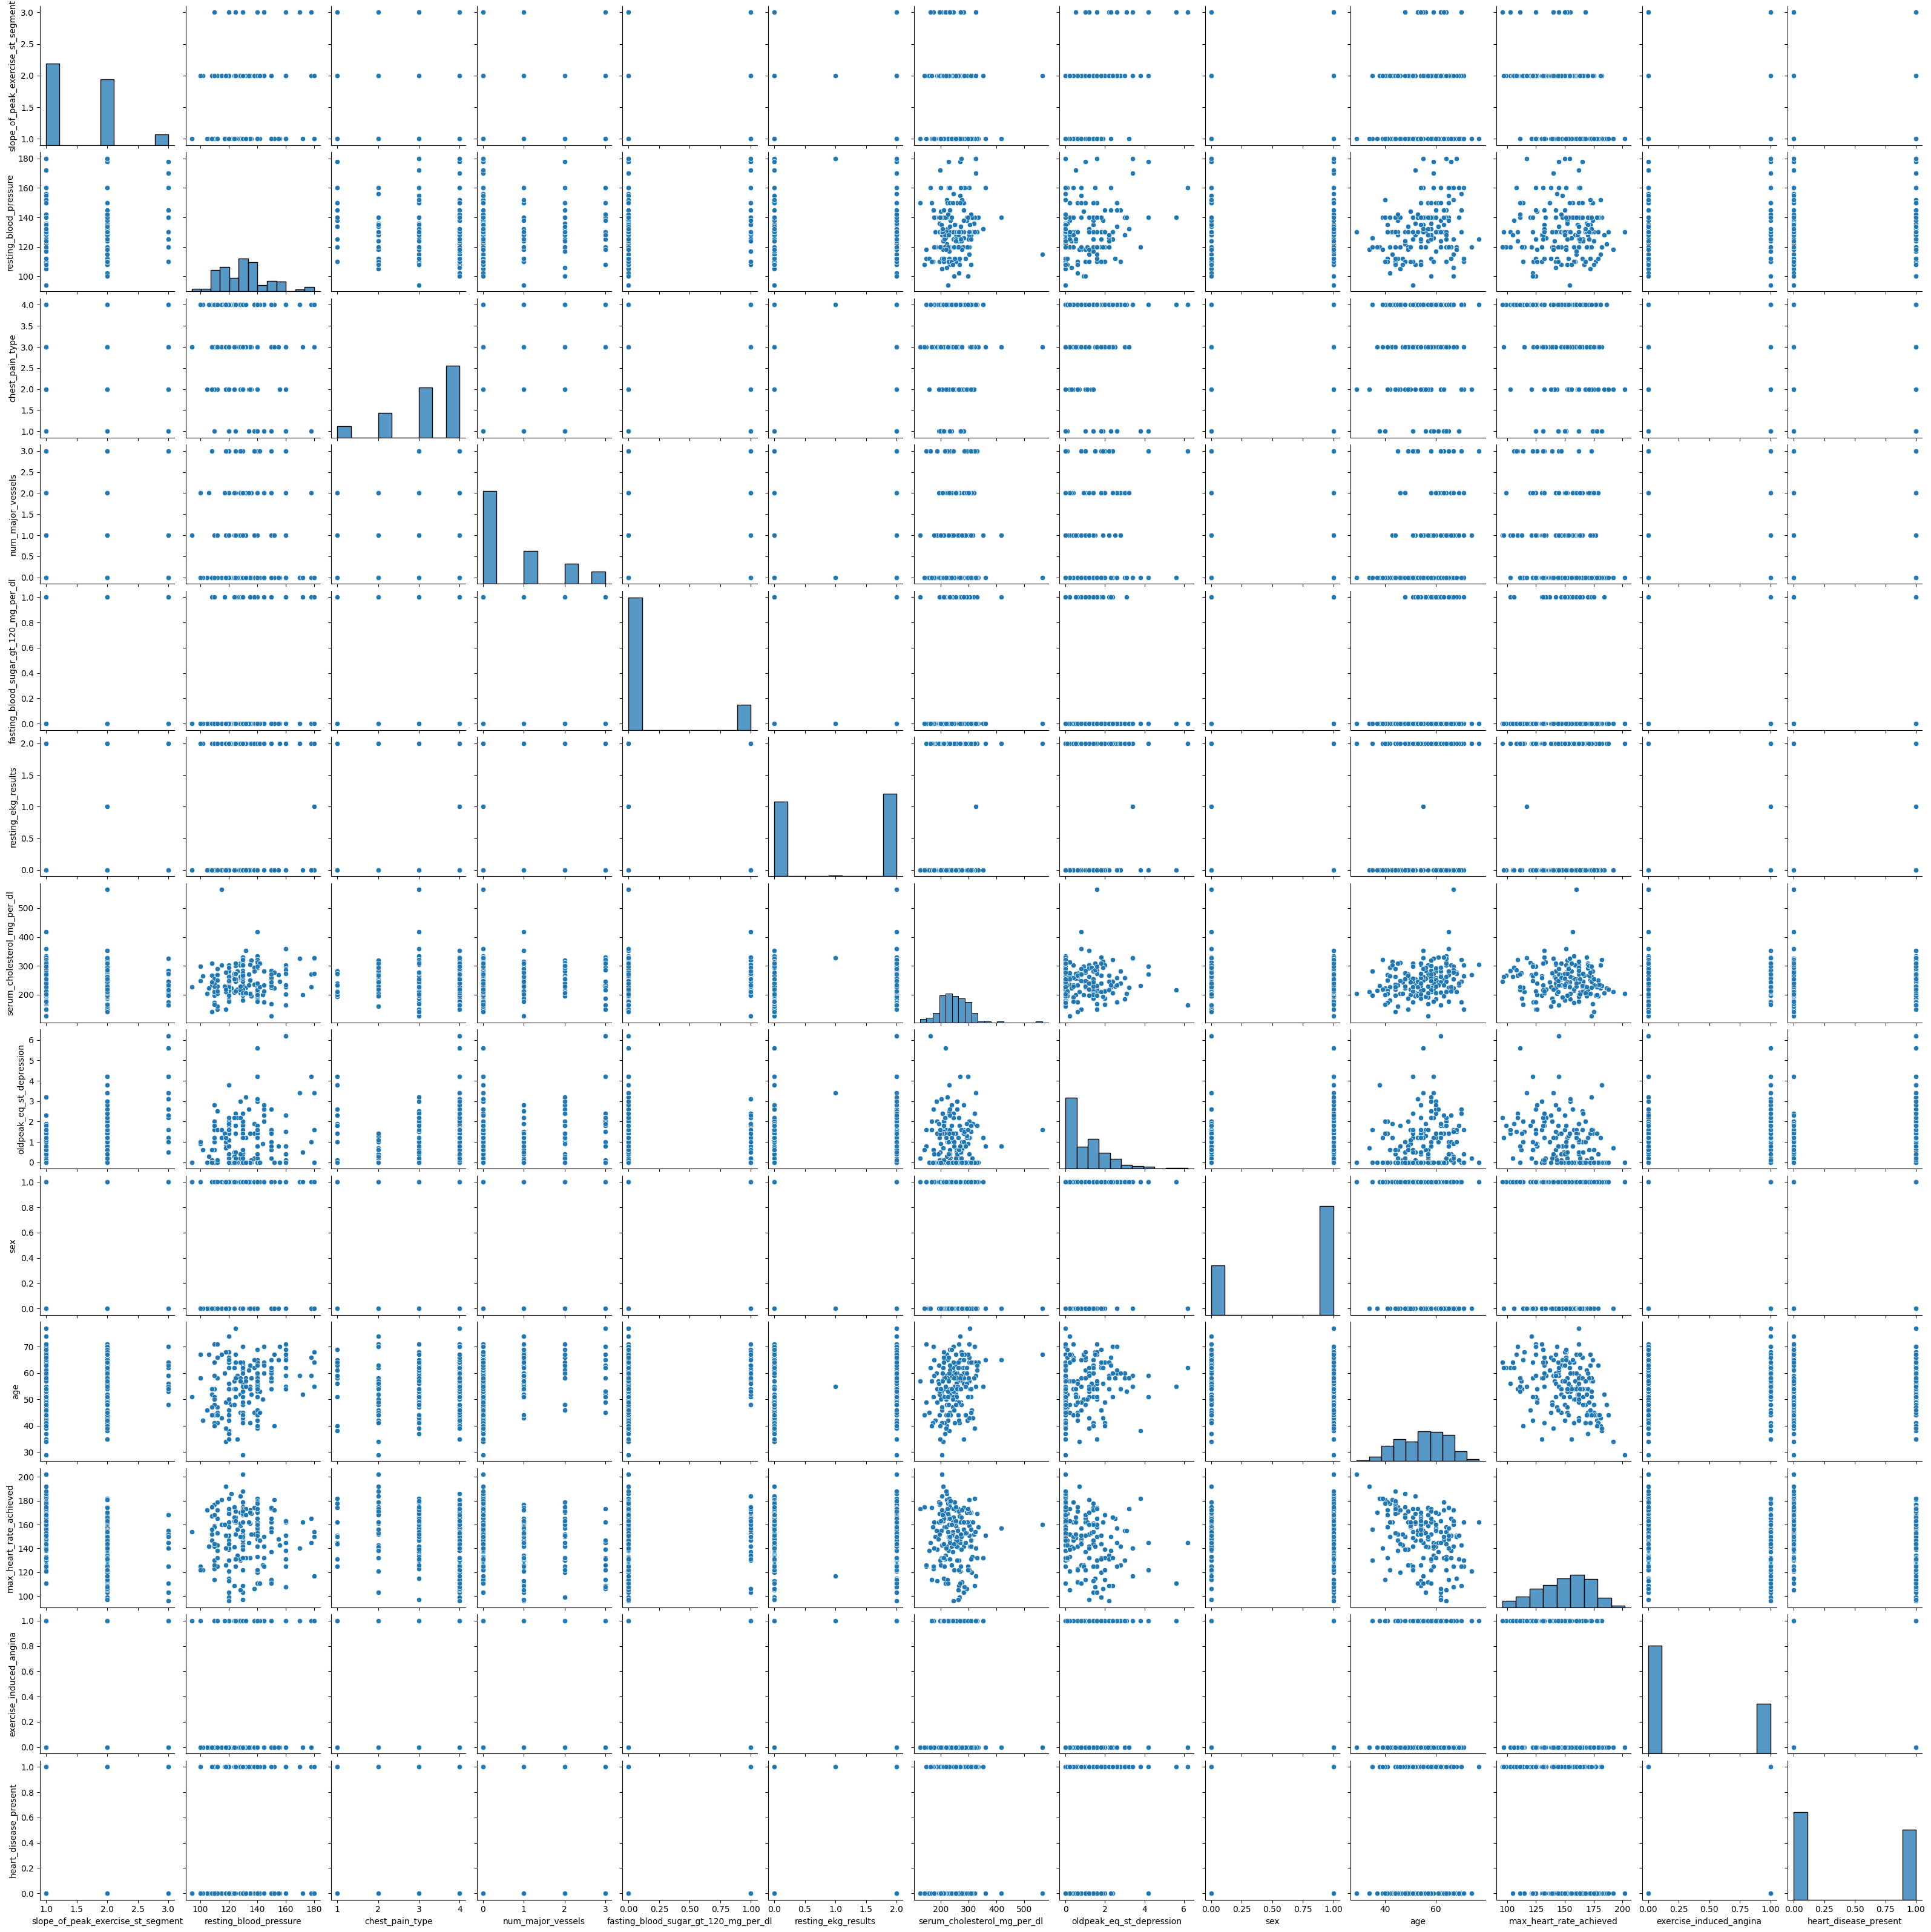

In [ ]:
#multivariate:
sns.pairplot(df)

#Data Preprocessing:

In [ ]:
#hnadling missing values:
df.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [ ]:
#checking correpted datas:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [ ]:
df['patient_id'].nunique()

180

In [ ]:
df['thal'].unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

In [ ]:
# drop_duplicates to remove duplicates but this datsets dosent contain duplicates

In [ ]:
col1=df.select_dtypes(include=['int','float']).columns
col1

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [ ]:
col2=df.select_dtypes(include=['object']).columns
col2

Index(['patient_id', 'thal'], dtype='object')

In [ ]:
#encoding--coverting catogorical datas into numerical form:
df = pd.get_dummies(df, columns=['thal'], drop_first=True, dtype=int)

In [ ]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present', 'thal_normal', 'thal_reversible_defect'],
      dtype='object')

In [ ]:
df = df.drop('thal_normal', axis=1)

In [ ]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present', 'thal_reversible_defect'],
      dtype='object')

In [ ]:
cols = [col for col in df.columns if col not in ['thal_reversible_defect', 'heart_disease_present']]
df = df[cols + ['thal_reversible_defect', 'heart_disease_present']]

In [ ]:
df

,patient_id,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,heart_disease_present
0,0z64un,1,128,2,0,0,2,308,0.0,1,45,170,0,0,0
1,ryoo3j,2,110,3,0,0,0,214,1.6,0,54,158,0,0,0
2,yt1s1x,1,125,4,3,0,2,304,0.0,1,77,162,1,0,1
3,l2xjde,1,152,4,0,0,0,223,0.0,1,40,181,0,1,1
4,oyt4ek,3,178,1,0,0,2,270,4.2,1,59,145,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,125,4,2,1,0,254,0.2,1,67,163,0,1,1
176,2s2b1f,2,180,4,0,0,1,327,3.4,0,55,117,1,0,1
177,nsd00i,2,125,3,0,0,0,309,1.8,1,64,131,1,1,1
178,0xw93k,1,124,3,2,1,0,255,0.0,1,48,175,0,0,0


In [ ]:
df = df.drop('patient_id', axis=1)

In [ ]:
df

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,heart_disease_present
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,0
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0,0
2,1,125,4,3,0,2,304,0.0,1,77,162,1,0,1
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1,1
4,3,178,1,0,0,2,270,4.2,1,59,145,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1,1
176,2,180,4,0,0,1,327,3.4,0,55,117,1,0,1
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1,1
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    int64  
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    int64  
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

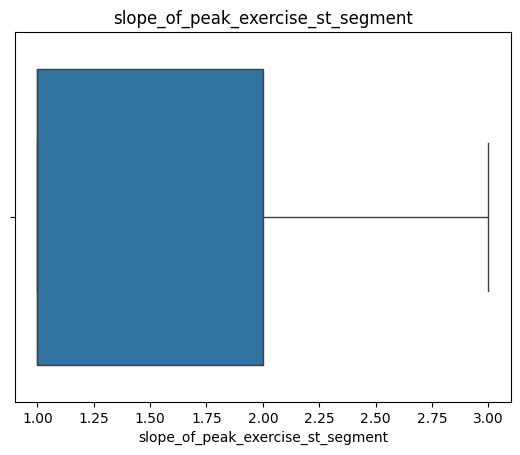

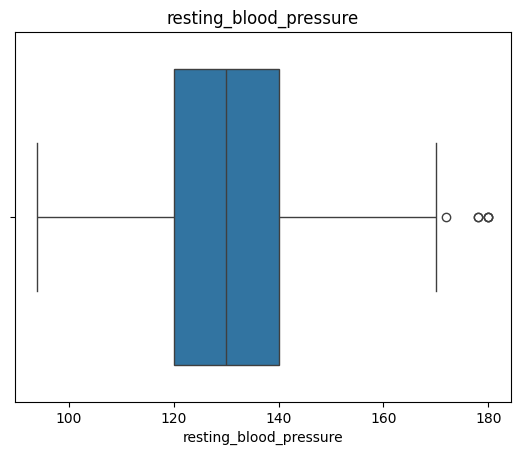

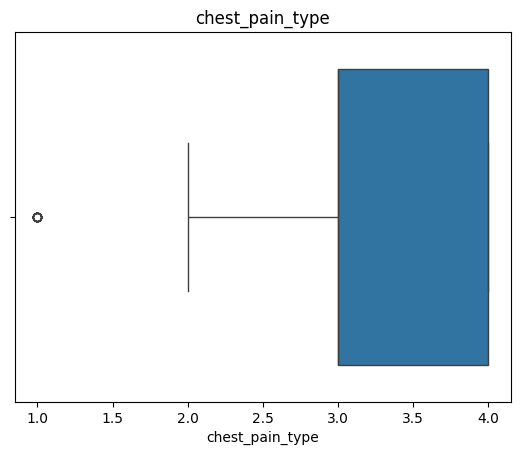

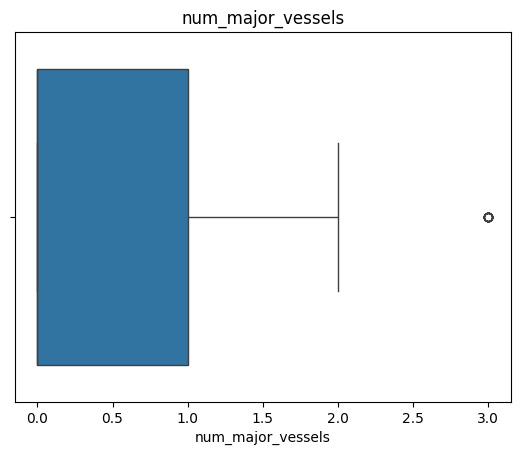

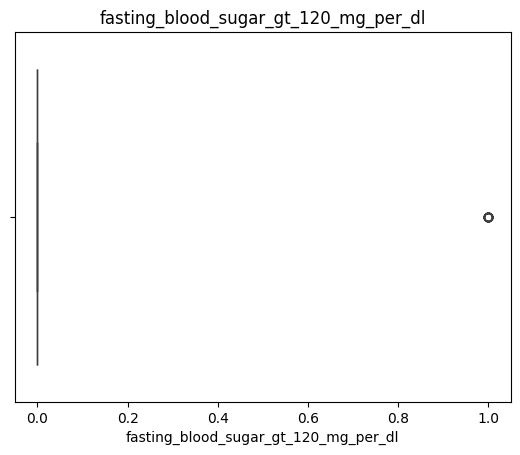

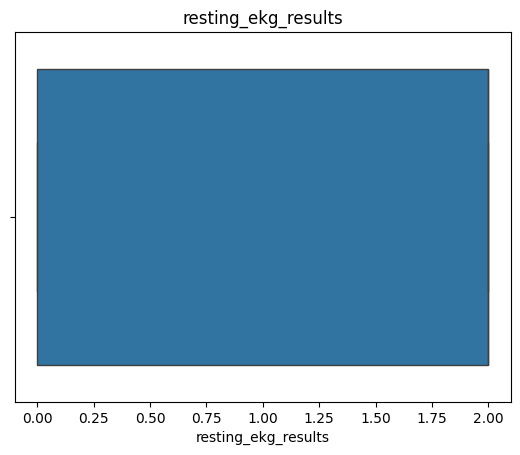

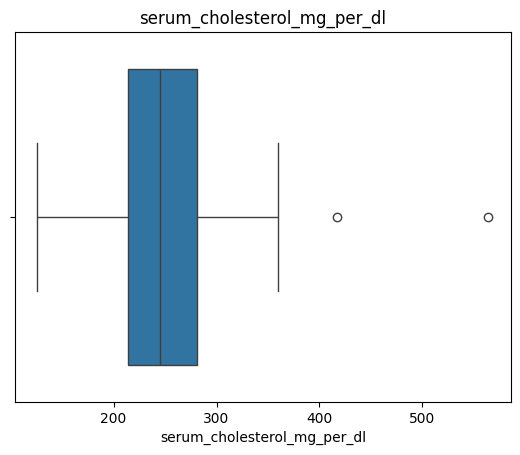

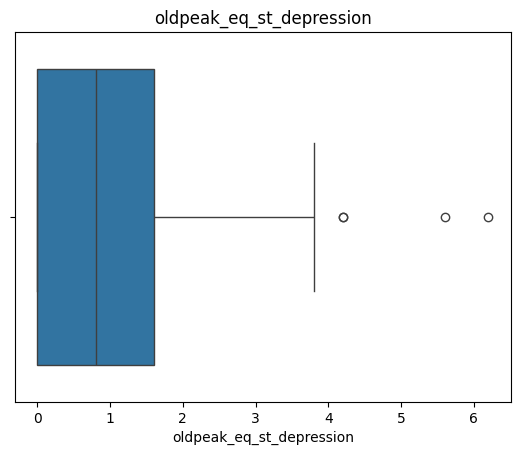

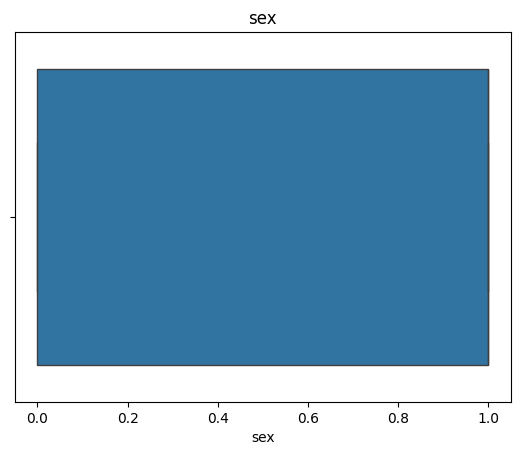

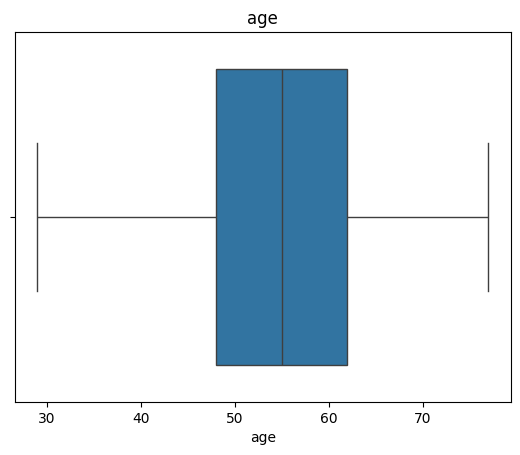

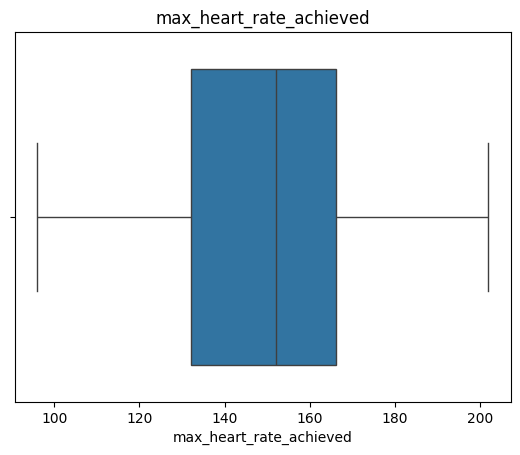

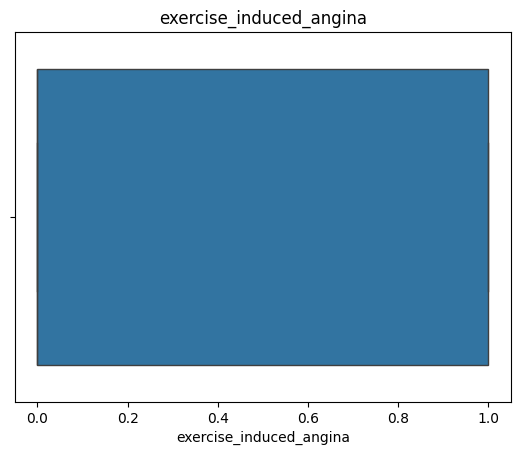

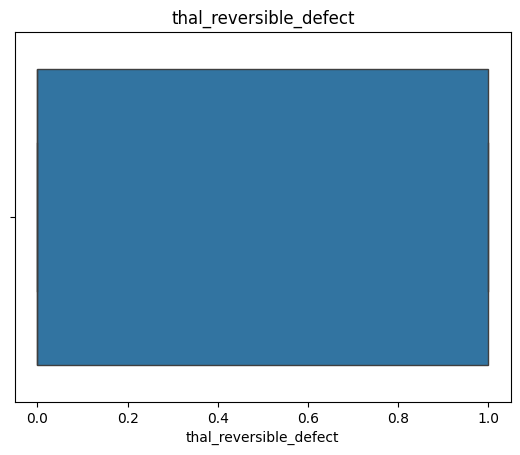

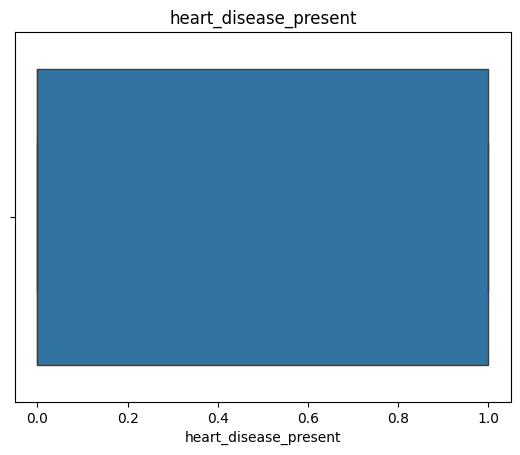

In [ ]:
#viewing outliers:
for col in df:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
# Step 1: Split
from sklearn.model_selection import train_test_split

X = df.drop('heart_disease_present', axis=1)
y = df['heart_disease_present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#handling outliers: capping
cols_to_cap = [
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'oldpeak_eq_st_depression'
]
bounds = {}

for col in cols_to_cap:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    bounds[col] = (lower, upper)

    X_train[col] = X_train[col].clip(lower, upper)

In [ ]:
for col in cols_to_cap:
    lower, upper = bounds[col]
    X_test[col] = X_test[col].clip(lower, upper)

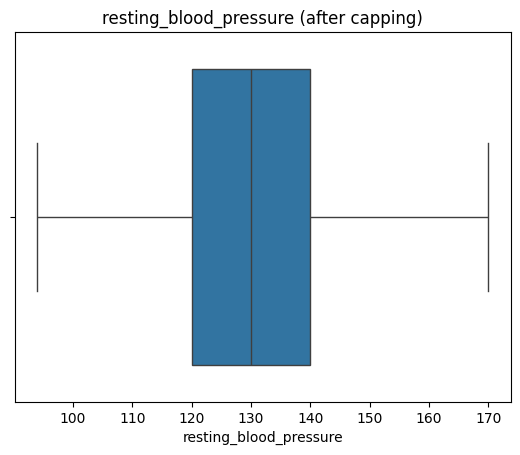

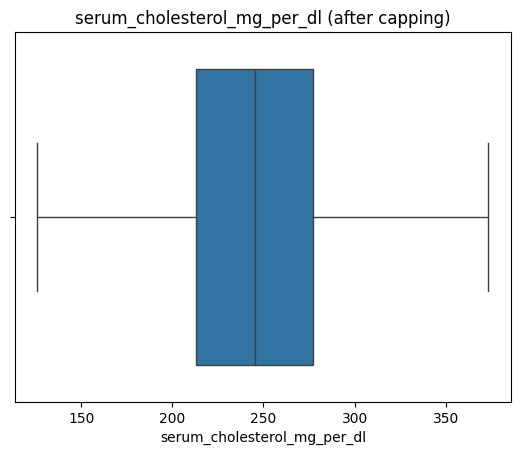

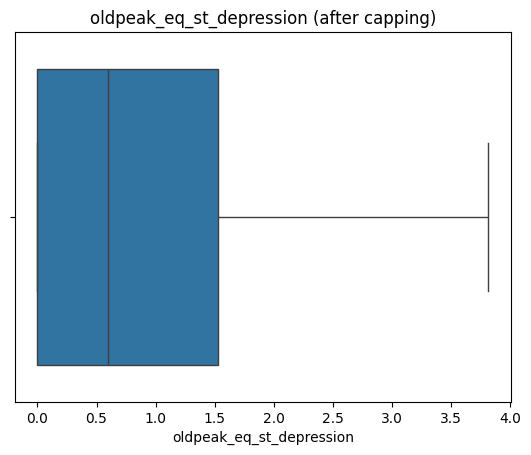

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_cap = [
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'oldpeak_eq_st_depression'
]

for col in cols_to_cap:
    plt.figure()
    sns.boxplot(x=X_train[col])
    plt.title(f"{col} (after capping)")
    plt.show()

In [ ]:
Q1 = X_train[cols_to_cap].quantile(0.25)
Q3 = X_train[cols_to_cap].quantile(0.75)
IQR = Q3 - Q1

outliers_after = ((X_train[cols_to_cap] < (Q1 - 1.5 * IQR)) |
                  (X_train[cols_to_cap] > (Q3 + 1.5 * IQR)))

outliers_after.sum()

,0
resting_blood_pressure,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [ ]:
X_train[cols_to_cap].describe()

,resting_blood_pressure,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression
count,144.000000,144.000000,144.000000
mean,131.208333,246.106771,0.938455
std,16.394983,46.166978,1.031243
min,94.000000,126.000000,0.000000
25%,120.000000,212.750000,0.000000
50%,130.000000,245.500000,0.600000
75%,140.000000,277.000000,1.525000
max,170.000000,373.375000,3.812500


In [ ]:
#Scaling:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_test = scaler.transform(X_test)         # transform test

In [ ]:
print("Mean:", X_train.mean(axis=0))
print("Std:", X_train.std(axis=0))

Mean: [ 1.29526020e-16 -5.76699182e-16 -4.93432455e-17 -7.40148683e-17
  4.93432455e-17  4.93432455e-17 -2.09708794e-16  1.04854397e-16
 -3.08395285e-17 -2.71387850e-16 -5.67447324e-16 -2.92975520e-17
 -2.46716228e-17]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
#data balancing:
y.value_counts(normalize=True)

,proportion
heart_disease_present,
0,0.555556
1,0.444444


#Feature selection:

In [ ]:
df.corr()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,heart_disease_present
slope_of_peak_exercise_st_segment,1.000000,0.098287,0.121207,0.076832,0.050199,0.172191,-0.032348,0.615948,0.093340,0.169918,-0.418102,0.225459,0.243341,0.344224
resting_blood_pressure,0.098287,1.000000,-0.029296,0.042388,0.166570,0.078986,0.144881,0.219026,-0.055589,0.284402,-0.017521,0.123397,0.046578,0.078506
chest_pain_type,0.121207,-0.029296,1.000000,0.249061,-0.088992,0.033379,0.061213,0.080799,0.086057,0.085001,-0.301792,0.346266,0.307524,0.412829
num_major_vessels,0.076832,0.042388,0.249061,1.000000,0.169792,0.096656,0.098348,0.214062,0.073107,0.347355,-0.275687,0.153407,0.194026,0.421519
fasting_blood_sugar_gt_120_mg_per_dl,0.050199,0.166570,-0.088992,0.169792,1.000000,0.053864,0.027560,-0.039055,0.066010,0.176101,0.058369,-0.005956,-0.028324,0.003379
resting_ekg_results,0.172191,0.078986,0.033379,0.096656,0.053864,1.000000,0.170839,0.097321,0.045786,0.126856,-0.102766,0.037773,-0.041946,0.145933
serum_cholesterol_mg_per_dl,-0.032348,0.144881,0.061213,0.098348,0.027560,0.170839,1.000000,-0.021932,-0.152296,0.236211,-0.071038,0.083139,0.015760,0.079775
oldpeak_eq_st_depression,0.615948,0.219026,0.080799,0.214062,-0.039055,0.097321,-0.021932,1.000000,0.099374,0.189700,-0.341045,0.249167,0.313616,0.382930
sex,0.093340,-0.055589,0.086057,0.073107,0.066010,0.045786,-0.152296,0.099374,1.000000,-0.148997,-0.053960,0.251096,0.366381,0.335421
age,0.169918,0.284402,0.085001,0.347355,0.176101,0.126856,0.236211,0.189700,-0.148997,1.000000,-0.394630,0.081811,0.020593,0.138255


In [ ]:
df[df>0.8]

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,heart_disease_present
0,1,128,2,NaN,NaN,2.0,308,NaN,1.0,45,170,NaN,NaN,NaN
1,2,110,3,NaN,NaN,NaN,214,1.6,NaN,54,158,NaN,NaN,NaN
2,1,125,4,3.0,NaN,2.0,304,NaN,1.0,77,162,1.0,NaN,1.0
3,1,152,4,NaN,NaN,NaN,223,NaN,1.0,40,181,NaN,1.0,1.0
4,3,178,1,NaN,NaN,2.0,270,4.2,1.0,59,145,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2.0,1.0,NaN,254,NaN,1.0,67,163,NaN,1.0,1.0
176,2,180,4,NaN,NaN,1.0,327,3.4,NaN,55,117,1.0,NaN,1.0
177,2,125,3,NaN,NaN,NaN,309,1.8,1.0,64,131,1.0,1.0,1.0
178,1,124,3,2.0,1.0,NaN,255,NaN,1.0,48,175,NaN,NaN,NaN


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming your preprocessed DataFrame is called df
# and target column is 'heart_disease_present'
X = df.drop(columns=['heart_disease_present'])  # predictors only

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display features with VIF > 5
print("All VIF values:\n", vif_data)
print("\nFeatures with high multicollinearity (VIF > 5):\n", vif_data[vif_data['VIF'] > 5])

All VIF values:
                                  feature        VIF
0      slope_of_peak_exercise_st_segment  12.127912
1                 resting_blood_pressure  67.395992
2                        chest_pain_type  14.466292
3                      num_major_vessels   2.037306
4   fasting_blood_sugar_gt_120_mg_per_dl   1.324216
5                    resting_ekg_results   2.308916
6            serum_cholesterol_mg_per_dl  25.724755
7               oldpeak_eq_st_depression   3.425358
8                                    sex   3.906193
9                                    age  43.336109
10               max_heart_rate_achieved  36.974773
11               exercise_induced_angina   2.121074
12                thal_reversible_defect   2.527497

Features with high multicollinearity (VIF > 5):
                               feature        VIF
0   slope_of_peak_exercise_st_segment  12.127912
1              resting_blood_pressure  67.395992
2                     chest_pain_type  14.466292
6        

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming your preprocessed DataFrame is 'df'
# and target column is 'heart_disease_present'

# Step 1: Create new composite features to replace high-VIF columns
df['age_maxHR_ratio'] = df['max_heart_rate_achieved'] / df['age']
df['bp_cholesterol_score'] = 0.5 * df['resting_blood_pressure'] + 0.5 * df['serum_cholesterol_mg_per_dl']
df['exercise_stress_index'] = df['slope_of_peak_exercise_st_segment'] * df['oldpeak_eq_st_depression']

# Step 2: Drop the original high-VIF features
df_model = df.drop(columns=[
    'age',
    'max_heart_rate_achieved',
    'resting_blood_pressure',
    'serum_cholesterol_mg_per_dl',
    'slope_of_peak_exercise_st_segment',
    'oldpeak_eq_st_depression'
])

# Step 3: Recalculate VIF to confirm multicollinearity is reduced
X = df_model.drop(columns=['heart_disease_present'])
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("VIF after creating composite features:\n", vif_data)

VIF after creating composite features:
                                 feature        VIF
0                       chest_pain_type  13.003524
1                     num_major_vessels   1.877711
2  fasting_blood_sugar_gt_120_mg_per_dl   1.272101
3                   resting_ekg_results   2.269384
4                                   sex   3.912033
5               exercise_induced_angina   1.984427
6                thal_reversible_defect   2.503221
7                       age_maxHR_ratio  11.213746
8                  bp_cholesterol_score  19.713004
9                 exercise_stress_index   1.756507


In [ ]:
df

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,heart_disease_present,age_maxHR_ratio,bp_cholesterol_score,exercise_stress_index
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,0,3.777778,218.0,0.0
1,2,110,3,0,0,0,214,1.6,0,54,158,0,0,0,2.925926,162.0,3.2
2,1,125,4,3,0,2,304,0.0,1,77,162,1,0,1,2.103896,214.5,0.0
3,1,152,4,0,0,0,223,0.0,1,40,181,0,1,1,4.525000,187.5,0.0
4,3,178,1,0,0,2,270,4.2,1,59,145,0,1,0,2.457627,224.0,12.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,125,4,2,1,0,254,0.2,1,67,163,0,1,1,2.432836,189.5,0.4
176,2,180,4,0,0,1,327,3.4,0,55,117,1,0,1,2.127273,253.5,6.8
177,2,125,3,0,0,0,309,1.8,1,64,131,1,1,1,2.046875,217.0,3.6
178,1,124,3,2,1,0,255,0.0,1,48,175,0,0,0,3.645833,189.5,0.0


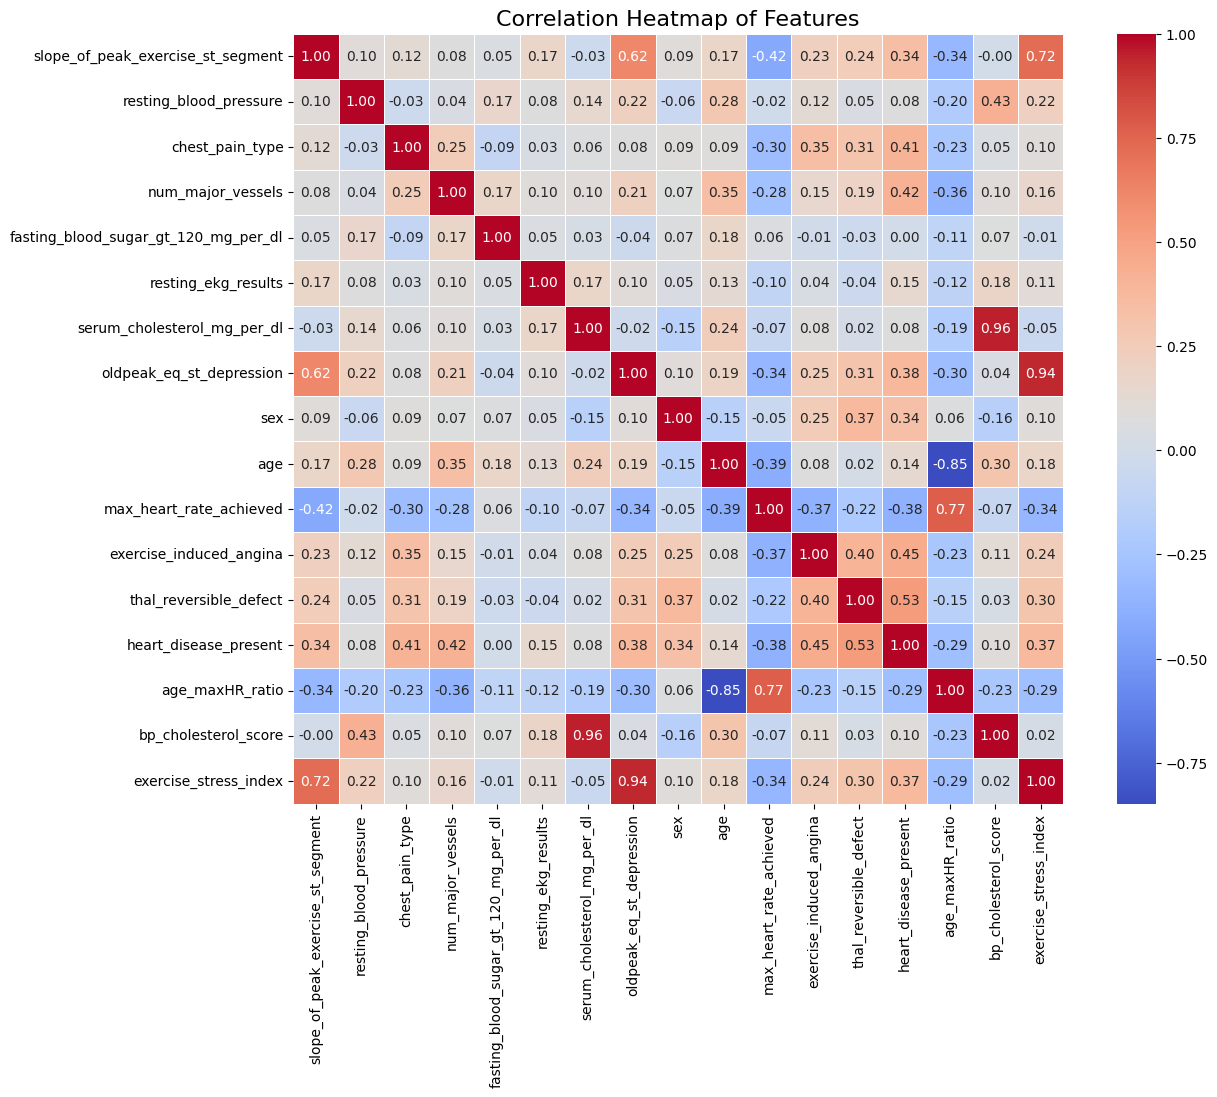

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()  # df is your full dataset including composite features

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,       # show correlation values
    fmt=".2f",        # format to 2 decimal places
    cmap="coolwarm",  # color map
    cbar=True,        # show color bar
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Features", fontsize=16)
plt.show()

#Model Evaluation:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate predictors and target
X = df.drop(columns=['heart_disease_present'])
y = df['heart_disease_present']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,age_maxHR_ratio,bp_cholesterol_score,exercise_stress_index
139,1,130,2,0,0,2,219,0.0,1,44,188,0,0,4.272727,174.5,0.0
0,1,128,2,0,0,2,308,0.0,1,45,170,0,0,3.777778,218.0,0.0
169,2,110,1,0,0,2,211,1.8,1,64,144,1,0,2.250000,160.5,3.6
65,1,126,4,0,0,2,282,0.0,1,35,156,1,1,4.457143,204.0,0.0
98,1,155,3,0,0,0,269,0.8,0,65,148,0,0,2.276923,212.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,1,160,3,1,0,0,201,0.0,0,54,163,0,0,3.018519,180.5,0.0
69,2,120,3,3,0,0,188,2.0,1,49,139,0,1,2.836735,154.0,4.0
48,2,120,2,1,0,2,281,1.4,1,62,103,0,1,1.661290,200.5,2.8
153,1,112,4,1,0,2,290,0.0,1,44,153,0,0,3.477273,201.0,0.0


In [ ]:
y_train

,heart_disease_present
139,0
0,0
169,0
65,1
98,0
...,...
179,0
69,1
48,1
153,1


In [ ]:
X_test

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,thal_reversible_defect,age_maxHR_ratio,bp_cholesterol_score,exercise_stress_index
24,1,156,2,0,0,2,245,0.0,1,70,143,0,0,2.042857,200.5,0.0
173,1,140,4,0,0,0,299,1.6,1,51,173,1,1,3.392157,219.5,1.6
81,2,120,4,1,0,0,188,1.4,1,54,113,0,1,2.092593,154.0,2.8
160,1,130,2,0,0,0,266,0.6,1,49,171,0,0,3.489796,198.0,0.6
35,1,122,4,0,0,2,222,0.0,1,48,186,0,0,3.875000,172.0,0.0
147,2,134,1,2,0,0,234,2.6,1,61,145,0,0,2.377049,184.0,5.2
33,1,180,4,0,0,0,325,0.0,0,64,154,1,0,2.406250,252.5,0.0
126,2,102,4,0,0,2,265,0.6,0,42,122,0,0,2.904762,183.5,1.2
4,3,178,1,0,0,2,270,4.2,1,59,145,0,1,2.457627,224.0,12.6
57,2,120,4,2,0,0,267,1.8,1,62,99,1,1,1.596774,193.5,3.6


In [ ]:
y_test

,heart_disease_present
24,0
173,1
81,1
160,0
35,0
147,1
33,0
126,0
4,0
57,1


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Dictionary to store best models
best_models = {}

# Models and hyperparameters
models = {
    'LogisticRegression': {
        'model': LogisticRegression(solver='liblinear'),
        'params': {
            'penalty': ['l1', 'l2'],
            'C': [0.01, 0.1, 1, 10, 100]
        },
        'search': 'grid'
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'search': 'grid'
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'search': 'grid'
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        },
        'search': 'grid'
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0]
        },
        'search': 'grid'
    },
    'SVM': {
        'model': SVC(probability=True),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['linear', 'rbf'],  # removed 'poly' for speed
            'gamma': ['scale', 'auto']
        },
        'search': 'random',  # use RandomizedSearchCV for SVM
        'n_iter': 10
    }
}

# Loop through models
for name, mp in models.items():
    print(f"\nTraining and tuning {name}...")

    if mp['search'] == 'grid':
        search = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='accuracy', n_jobs=-1)
    else:  # random search for SVM
        search = RandomizedSearchCV(
            mp['model'],
            param_distributions=mp['params'],
            n_iter=mp['n_iter'],
            cv=5,
            scoring='accuracy',
            n_jobs=-1,
            random_state=42
        )

    search.fit(X_train, y_train)

    print(f"Best parameters for {name}: {search.best_params_}")

    y_pred = search.predict(X_test)
    print(f"Accuracy on test set: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    best_models[name] = search.best_estimator_


Training and tuning LogisticRegression...
Best parameters for LogisticRegression: {'C': 1, 'penalty': 'l1'}
Accuracy on test set: 0.8889
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36


Training and tuning DecisionTree...
Best parameters for DecisionTree: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Accuracy on test set: 0.8056
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        3

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Accuracy on test set: 0.8889
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.83      0.94      0.88        16

    accuracy                           0.89        36
   macro avg       0.89      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36


Training and tuning SVM...
Best parameters for SVM: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}
Accuracy on test set: 0.8611
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.82      0.88      0.85        16

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36



In [ ]:
## Step for Prediction
# Used the best_model obtained from the model training and selection step
y_pred=best_model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1])

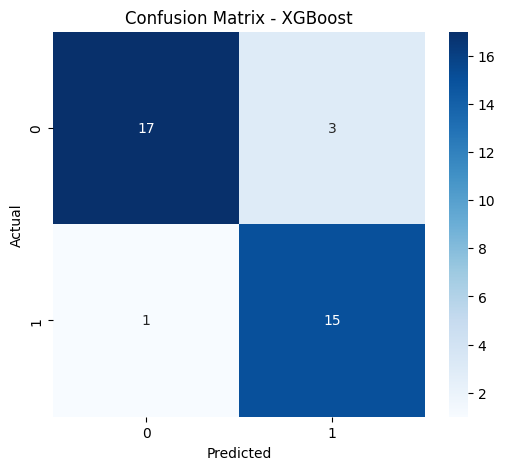

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = best_models['XGBoost']
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Conclusion

- Machine learning models were used to predict heart disease.  
- XGBoost ( best model) gave the best performance.